In [5]:
import numpy as np
import scipy.stats as stats
import pandas as pd

def extract_features(signal):
    """
    Recibe una serie de Pandas (los 20,480 números de un rodamiento) 
    y devuelve un diccionario con 4 características matemáticas.
    """
    # 1. RMS (Root Mean Square) -> Raíz de la media de los cuadrados
    rms = np.sqrt(np.mean(signal**2))
    
    # 2. Peak-to-Peak -> Máximo - Mínimo
    p2p = np.max(signal) - np.min(signal)
    
    # 3. Kurtosis -> Usa scipy.stats.kurtosis
    kurt = stats.kurtosis(signal)
    
    # 4. Skewness -> Usa scipy.stats.skew
    skew = stats.skew(signal)
    
    return {
        'RMS': rms,
        'Peak_to_Peak': p2p,
        'Kurtosis': kurt,
        'Skewness': skew
    }

# --- VAMOS A PROBARLA ---
# Cargamos el archivo SANO (Día 1)
path_sano = '../data/raw/2nd_test/2004.02.12.10.32.39'
df_sano = pd.read_csv(path_sano, sep='\t', header=None)

# Cargamos un archivo ENFERMO (Justo el pico antes de morir. Ej: el archivo 980 de tu lista)
# (Sustituye este nombre por uno que esté cerca del final, antes de la caída a cero)
path_enfermo = '../data/raw/2nd_test/2004.02.19.05.52.39' 
df_enfermo = pd.read_csv(path_enfermo, sep='\t', header=None)

print("--- CARACTERÍSTICAS RODAMIENTO SANO ---")
features_sano = extract_features(df_sano[0]) # [0] es el Rodamiento 1
for k, v in features_sano.items():
    print(f"{k}: {v:.5f}")

print("\n--- CARACTERÍSTICAS RODAMIENTO ENFERMO ---")
features_enfermo = extract_features(df_enfermo[0])
for k, v in features_enfermo.items():
    print(f"{k}: {v:.5f}")

--- CARACTERÍSTICAS RODAMIENTO SANO ---
RMS: 0.07418
Peak_to_Peak: 0.84000
Kurtosis: 0.62876
Skewness: 0.08399

--- CARACTERÍSTICAS RODAMIENTO ENFERMO ---
RMS: 0.46201
Peak_to_Peak: 5.56900
Kurtosis: 3.75997
Skewness: -0.32537


In [6]:
import os
import pandas as pd

# Asumimos que la función 'extract_features' que creamos antes sigue en la memoria del notebook

data_dir = '../data/raw/2nd_test/'
files = sorted(os.listdir(data_dir))

# Esta lista será nuestro nuevo "Excel" en blanco
todas_las_caracteristicas = []

print("Extrayendo características de todos los archivos... ¡Paciencia!")

for i, filename in enumerate(files):
    filepath = os.path.join(data_dir, filename)
    
    # 1. Leer archivo
    df = pd.read_csv(filepath, sep='\t', header=None)
    
    # 2. Extraer caracteristicas SOLO del Rodamiento 1 (Columna 0)
    features = extract_features(df[0])
    
    # 3. Añadir el nombre del archivo para saber en qué momento estamos
    features['Archivo'] = filename
    
    # 4. Guardar la fila en nuestra lista maestra
    todas_las_caracteristicas.append(features)
    
    # Barra de progreso
    if i % 100 == 0:
        print(f"Procesado: {i}/{len(files)}")
        
# 5. Convertir la lista en un DataFrame de Pandas (nuestra tabla limpia)
df_features = pd.DataFrame(todas_las_caracteristicas)

# Reordenamos las columnas para que el nombre del archivo salga el primero
columnas = ['Archivo', 'RMS', 'Peak_to_Peak', 'Kurtosis', 'Skewness']
df_features = df_features[columnas]

# 6. GUARDAR EL TESORO en la carpeta de procesados
# Creamos la carpeta si por algún casual no existía
os.makedirs('../data/processed/', exist_ok=True)

ruta_guardado = '../data/processed/bearing_1_features.csv'
df_features.to_csv(ruta_guardado, index=False)

print(f"\n¡Éxito! Dataset procesado guardado en: {ruta_guardado}")
print("Primeras 5 filas de tu nuevo dataset:")
print(df_features.head())

Extrayendo características de todos los archivos... ¡Paciencia!
Procesado: 0/984
Procesado: 100/984
Procesado: 200/984
Procesado: 300/984
Procesado: 400/984
Procesado: 500/984
Procesado: 600/984
Procesado: 700/984
Procesado: 800/984
Procesado: 900/984

¡Éxito! Dataset procesado guardado en: ../data/processed/bearing_1_features.csv
Primeras 5 filas de tu nuevo dataset:
               Archivo       RMS  Peak_to_Peak  Kurtosis  Skewness
0  2004.02.12.10.32.39  0.074179         0.840  0.628763  0.083993
1  2004.02.12.10.42.39  0.075382         0.757  0.648291  0.052142
2  2004.02.12.10.52.39  0.076230         0.903  0.513475  0.032808
3  2004.02.12.11.02.39  0.078724         1.184  1.157953  0.041486
4  2004.02.12.11.12.39  0.078474         0.782  0.603177  0.028224


In [3]:
import pandas as pd
import os

# 1. Definimos la ruta
# NOTA: Si te da error de "File not found", asegúrate de que la ruta es correcta
# desde donde está tu notebook.
archivo_path = '../data/raw/2nd_test/2004.02.12.10.32.39'

# 2. Cargamos el archivo (AQUÍ ESTÁ LA MAGIA)
# sep='\t' -> Le dice a pandas que las columnas están separadas por tabulaciones
# header=None -> Le dice que la primera fila NO son títulos, son datos
df = pd.read_csv(archivo_path, sep='\t', header=None)

# 3. Ahora sí, df existe. ¡Imprimimos!
print("Primeras 5 filas:")
print(df.head())

print("\nDimensiones del archivo (Filas, Columnas):")
print(df.shape)

Primeras 5 filas:
       0      1      2      3
0 -0.049 -0.071 -0.132 -0.010
1 -0.042 -0.073 -0.007 -0.105
2  0.015  0.000  0.007  0.000
3 -0.051  0.020 -0.002  0.100
4 -0.107  0.010  0.127  0.054

Dimensiones del archivo (Filas, Columnas):
(20480, 4)


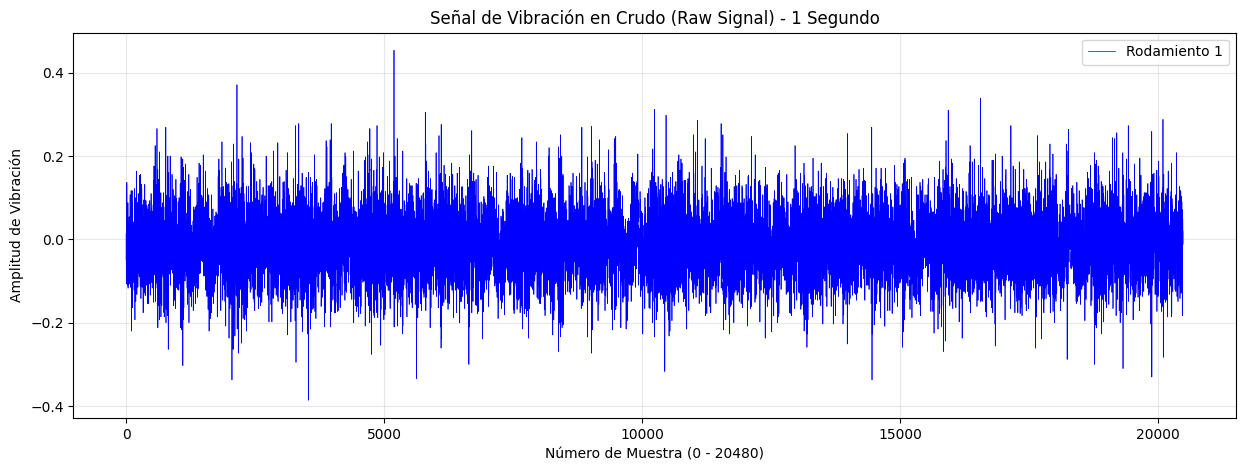

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Vamos a poner nombres a las columnas para no liarnos
# Según la documentación del dataset, son los 4 rodamientos (B1, B2, B3, B4)
df.columns = ['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4']

# 2. Configuración de la gráfica (Tamaño: 15 pulgadas de ancho, 5 de alto)
plt.figure(figsize=(15, 5))

# 3. Pintamos SOLO el Rodamiento 1
# Eje X: El índice (tiempo)
# Eje Y: La amplitud de la vibración
plt.plot(df['Bearing 1'], label='Rodamiento 1', color='blue', linewidth=0.5)

# 4. Etiquetas para que parezca profesional
plt.title('Señal de Vibración en Crudo (Raw Signal) - 1 Segundo')
plt.xlabel('Número de Muestra (0 - 20480)')
plt.ylabel('Amplitud de Vibración')
plt.legend()
plt.grid(True, alpha=0.3) # Una rejilla suave ayuda a leer

# 5. ¡Muestra la magia!
plt.show()

Cargando archivo del fallo: 2004.02.19.06.22.39


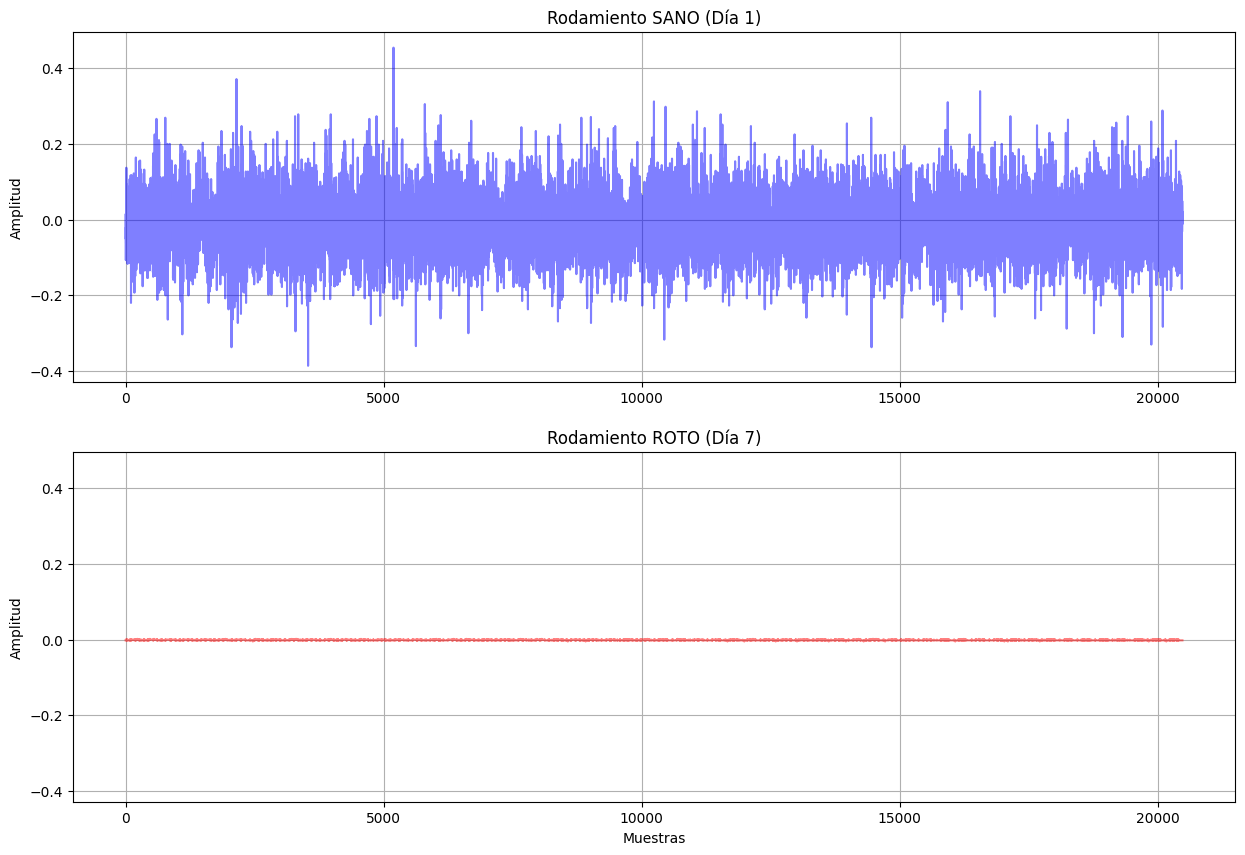

In [5]:
import os

# 1. Buscamos el ÚLTIMO archivo de la carpeta (El momento de la muerte del rodamiento)
data_dir = '../data/raw/2nd_test/'
files = sorted(os.listdir(data_dir)) # Ordenamos por fecha
last_file_name = files[-1] # El último de la lista

print(f"Cargando archivo del fallo: {last_file_name}")

# 2. Lo cargamos en un nuevo DataFrame llamado 'df_fallo'
path_fallo = os.path.join(data_dir, last_file_name)
df_fallo = pd.read_csv(path_fallo, sep='\t', header=None)
df_fallo.columns = ['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4']

# 3. ¡LA BATALLA! Graficamos Sano vs Roto (Usando subplots para comparar mejor)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharey=True) # sharey=True obliga a usar la misma escala vertical

# Gráfica 1: El Sano (Primer día)
# (Usamos df, que cargaste antes)
ax1.plot(df['Bearing 1'], color='blue', alpha=0.5)
ax1.set_title('Rodamiento SANO (Día 1)')
ax1.set_ylabel('Amplitud')
ax1.grid(True)

# Gráfica 2: El Roto (Último día)
ax2.plot(df_fallo['Bearing 1'], color='red', alpha=0.5)
ax2.set_title('Rodamiento ROTO (Día 7)')
ax2.set_xlabel('Muestras')
ax2.set_ylabel('Amplitud')
ax2.grid(True)

plt.show()

In [6]:
# 1. ¿Qué archivo hemos cargado realmente?
print(f"ARCHIVO CARGADO: {last_file_name}")

# 2. Vamos a ver las estadísticas brutas (La prueba del polígrafo)
# .describe() nos da el mínimo, máximo, media, etc.
print("\n--- Estadísticas del Rodamiento SANO (Azul) ---")
print(df['Bearing 1'].describe())

print("\n--- Estadísticas del Rodamiento ROTO (Rojo) ---")
print(df_fallo['Bearing 1'].describe())

ARCHIVO CARGADO: 2004.02.19.06.22.39

--- Estadísticas del Rodamiento SANO (Azul) ---
count    20480.000000
mean        -0.010196
std          0.073477
min         -0.386000
25%         -0.059000
50%         -0.010000
75%          0.037000
max          0.454000
Name: Bearing 1, dtype: float64

--- Estadísticas del Rodamiento ROTO (Rojo) ---
count    20480.000000
mean        -0.001162
std          0.001000
min         -0.005000
25%         -0.002000
50%         -0.002000
75%          0.000000
max          0.002000
Name: Bearing 1, dtype: float64


Procesando 984 archivos... (Esto puede tardar un poco)
Procesado: 0/984
Procesado: 100/984
Procesado: 200/984
Procesado: 300/984
Procesado: 400/984
Procesado: 500/984
Procesado: 600/984
Procesado: 700/984
Procesado: 800/984
Procesado: 900/984
¡Procesamiento completado!


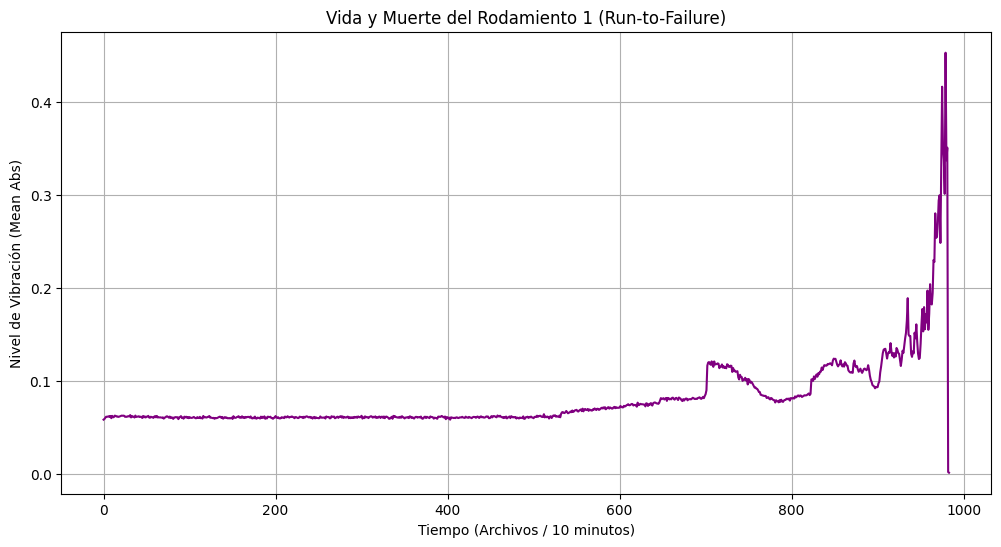

In [7]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

data_dir = '../data/raw/2nd_test/'
# Ordenamos para asegurar que vamos del pasado al futuro
files = sorted(os.listdir(data_dir))

# Aquí guardaremos la "salud" del rodamiento en cada momento
health_indicator = []

print(f"Procesando {len(files)} archivos... (Esto puede tardar un poco)")

for i, filename in enumerate(files):
    # 1. Cargar archivo
    filepath = os.path.join(data_dir, filename)
    df = pd.read_csv(filepath, sep='\t', header=None)
    
    # 2. Calcular la vibración media del Rodamiento 1 (Columna 0)
    # Usamos abs() porque la vibración oscila y no queremos que se anulen los positivos con negativos
    bearing_vibration = df[0].abs().mean()
    
    # 3. Guardar en la lista
    health_indicator.append(bearing_vibration)
    
    # Barra de progreso simple cada 100 archivos
    if i % 100 == 0:
        print(f"Procesado: {i}/{len(files)}")

print("¡Procesamiento completado!")

# --- VISUALIZACIÓN MAESTRA ---
plt.figure(figsize=(12, 6))
plt.plot(health_indicator, color='purple')
plt.title('Vida y Muerte del Rodamiento 1 (Run-to-Failure)')
plt.xlabel('Tiempo (Archivos / 10 minutos)')
plt.ylabel('Nivel de Vibración (Mean Abs)')
plt.grid(True)
plt.show()